In [ ]:
# @title
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).




<img src="/content/pipeline.svg" width="600">

In [ ]:
# @title
import os

from IPython.display import SVG,display

# Carpeta del proyecto
os.chdir('/content/drive/MyDrive/tutorial-sklearn-master/notebooks-spanish/')
#print(os.getcwd())
# Verifica que estás en el lugar correcto listando los archivos
#!ls

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Encadenando los estimadores con tuberías (*pipelines*)

En esta sección, estudiamos cómo encadenar los estimadores.

## Un ejemplo sencillo: extracción de características y selección antes de aplicar un estimador

### Extracción de características: vectorizer

Para algunos tipos de datos, por ejemplo, para datos de tipo texto, debemos aplicar un paso de extracción de características para convertirlos en características numéricas. Para demostrarlo, vamos a cargar el dataset de *spam* que utilizamos previamente.

In [ ]:
import os
with open(os.path.join("datasets", "smsspam", "SMSSpamCollection")) as f:
    lines = [line.strip().split("\t") for line in f.readlines()]
text = [x[1] for x in lines]
y = [x[0] == "ham" for x in lines]

In [ ]:
from sklearn.model_selection import train_test_split

text_train, text_test, y_train, y_test = train_test_split(text, y)

Hemos aplicado extracción de características manualmente del siguiente modo:

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

vectorizer = TfidfVectorizer()
vectorizer.fit(text_train)

X_train = vectorizer.transform(text_train)
X_test = vectorizer.transform(text_test)

clf = LogisticRegression()
clf.fit(X_train, y_train)

clf.score(X_test, y_test)

0.975609756097561

El aprender una transformación y luego aplicarla a los datos de test es muy común en aprendizaje automático. Por tanto, scikit-learn tiene una forma cómoda de hacer esto, llamada tuberías (*pipelines*):

In [ ]:
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(TfidfVectorizer(), LogisticRegression())
pipeline.fit(text_train, y_train)
pipeline.score(text_test, y_test)

0.9748923959827833

Como puedes comprobar, esto hace el código mucho más corto y fácil de manejar. Realmente, está ejecutándose exactamente lo mismo. Cuando llamamos a ``fit`` en la tubería, se llamará a cada método de forma sucesiva.

Después del primer ajuste, se utilizará el método ``transform`` para crear una nueva representación. Ésta se utilizará como entrada en el método ``fit`` del siguiente paso, y así sucesivamente. En el último paso, no se llamará a ``transform``.

![pipeline](/figures/pipeline.svg)



Si llamamos a ``score``, solo se llamará a ``transform`` en cada paso, generando lo que serían los datos de test. Al final aplicaremos ``score`` sobre la representación final obtenida. Lo mismo pasa para ``predict``.

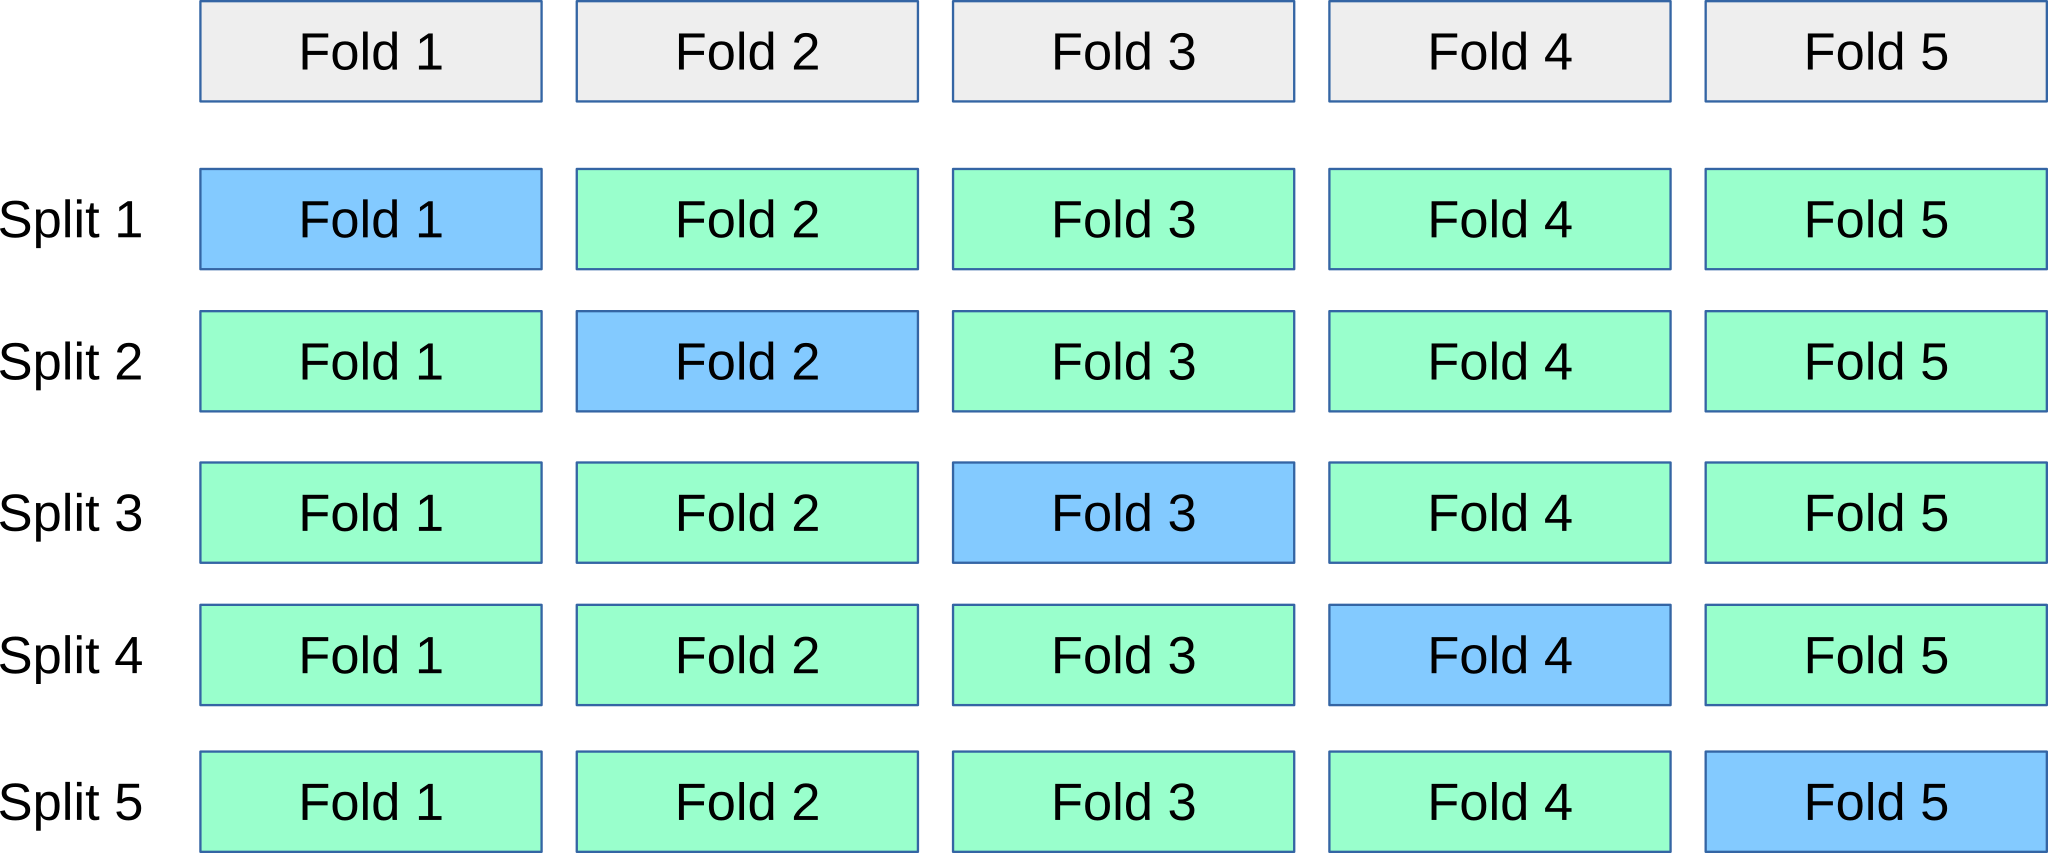

In [ ]:
# @title

display(SVG(f"{os.getcwd()}/figures/cross_validation.svg"))

Construir tuberías no solo nos permite simplificar el código, también es muy importante para el ajuste de parámetros. Imaginemos que queremos ajustar el parámetro $C$ de la regresión logística anterior.

Lo podríamos hacer de la siguiente forma (incorrecta):

In [ ]:
# Este código ilustra un error común, ¡no lo utilices!
from sklearn.model_selection import GridSearchCV

vectorizer = TfidfVectorizer()
vectorizer.fit(text_train)

X_train = vectorizer.transform(text_train)
X_test = vectorizer.transform(text_test)

clf = LogisticRegression()
grid = GridSearchCV(clf, param_grid={'C': [.01, .1, 1, 10, 100]}, cv=5)
grid.fit(X_train, y_train)
grid.score(X_test, y_test)

### 2.1.2 ¿Qué hemos hecho mal?

Hemos aplicado búsqueda *grid* con validación cruzada utilizando ``X_train``. Sin embargo, cuando aplicamos ``TfidfVectorizer`` estamos considerando el conjunto ``X_train`` completo, no solo los folds de entrenamiento. Por tanto, podríamos estar usando conocimiento acerca de la frecuencia de las palabras en los *folds* de test. Esto se llama "contaminación" del conjunto de test y lleva a estimaciones demasiado optimistas del rendimiento de generalización o a parámetros seleccionados de forma incorrecta. Sin embargo, podemos arreglar esto con una tubería:

In [ ]:
from sklearn.model_selection import GridSearchCV

pipeline = make_pipeline(TfidfVectorizer(),
                         LogisticRegression())

grid = GridSearchCV(pipeline,
                    param_grid={'logisticregression__C': [.01, .1, 1, 10, 100]}, cv=5)

grid.fit(text_train, y_train)
grid.score(text_test, y_test)

Observa que tenemos que indicar en que parte de la tubería aparece el parámetro $C$. Esto lo hacemos con la sintaxis especial ``__``. El nombre que hay antes del ``__`` es simplemente el nombre de la clase en minúscula, la parte que hay después de ``__`` es el parámetro que queremos ajustar por búsqueda *grid*.

<img src="figures/pipeline_cross_validation.svg" width="50%">

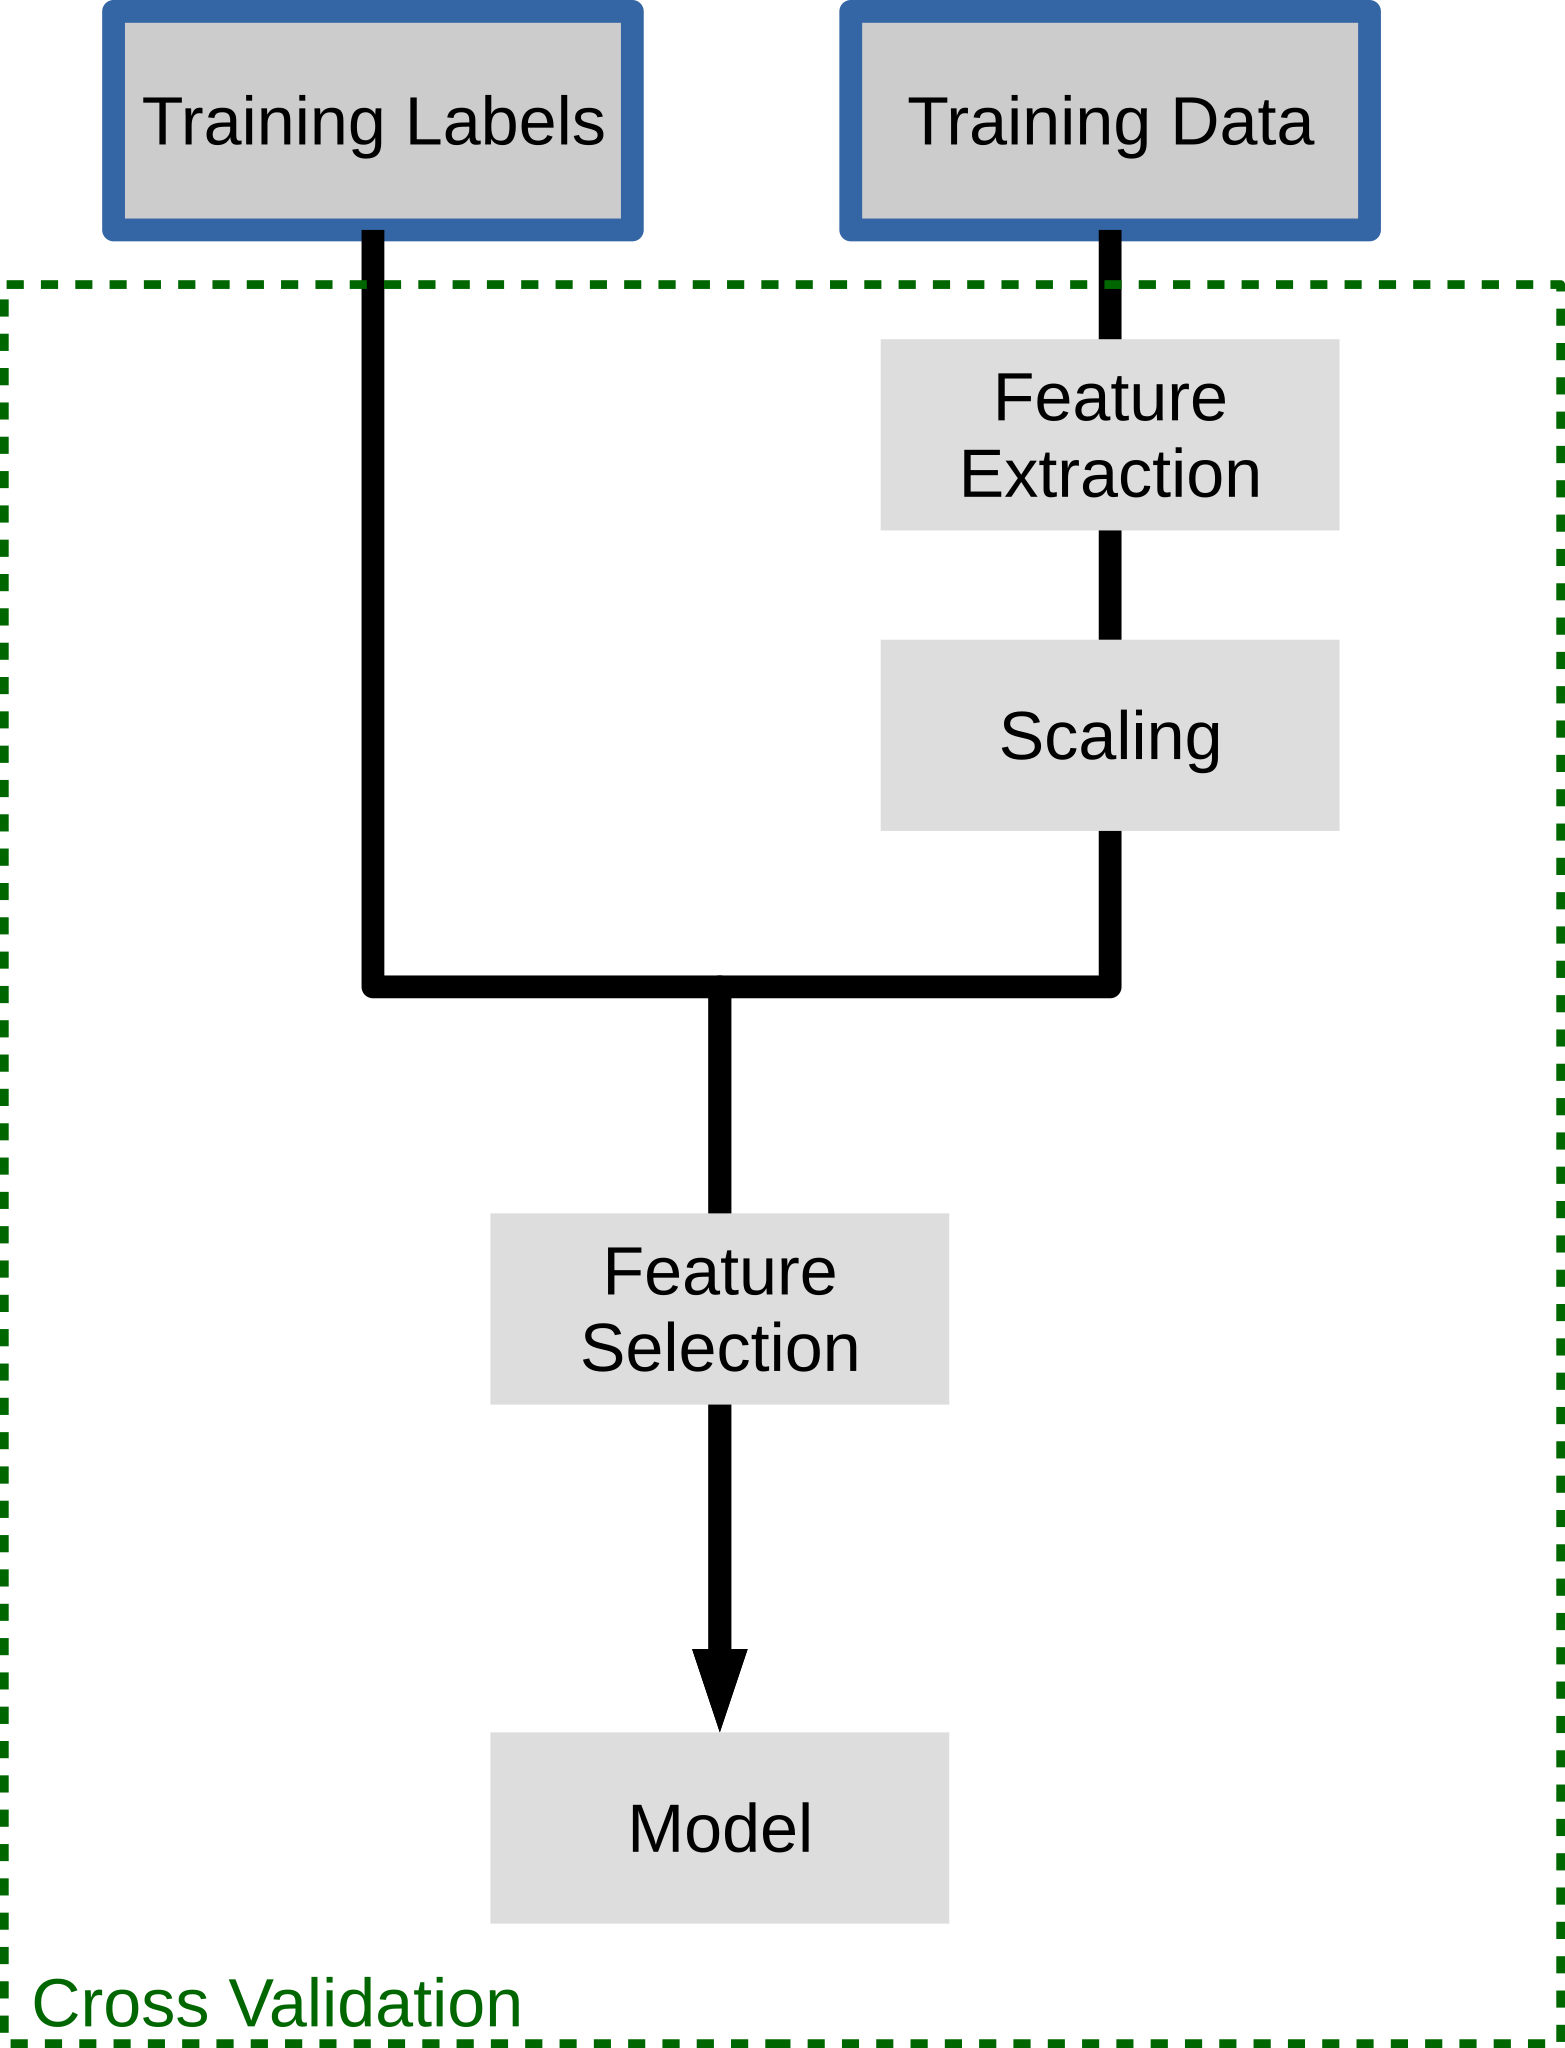

In [ ]:
# @title
display(SVG(f"{os.getcwd()}/figures/pipeline_cross_validation.svg"))

Otro beneficio de considerar tuberías es que podemos buscar sobre los propios parámetros de los algoritmos de extracción de características mediante el uso de ``GridSearchCV``:

In [ ]:
#Este código puede tardar bastante tiempo
from sklearn.model_selection import GridSearchCV

pipeline = make_pipeline(TfidfVectorizer(), LogisticRegression())

params = {'logisticregression__C': [.1, 1, 10, 100],
          "tfidfvectorizer__ngram_range": [(1, 1), (1, 2), (2, 2)]}
grid = GridSearchCV(pipeline, param_grid=params, cv=5)
grid.fit(text_train, y_train)
print(grid.best_params_)
grid.score(text_test, y_test)

{'logisticregression__C': 100, 'tfidfvectorizer__ngram_range': (1, 2)}


0.9827833572453372

<div class="alert alert-success">
    <b>EJERCICIO</b>:
     <ul>
      <li>
      Crea una tubería utilizando un ``StandardScaler`` y una regresión ``RidgeRegression`` y aplícala al dataset Boston housing (que se puede cargar con ``sklearn.datasets.load_boston``). Añade el transformador ``sklearn.preprocessing.PolynomialFeatures`` como una segunda fase de pre-procesamiento, y haz una búsqueda *grid* sobre el grado de los polinomios (prueba con grados 1, 2 y 3).
      </li>
    </ul>
</div>

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge

# 1. Cargar el dataset de California
data = fetch_california_housing()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Crear el "Núcleo" (Pipeline)
# Fíjate que el orden importa: 1º Escalar, 2º Crear Polinomios, 3º Modelo
pipeline_california = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures()),
    ('ridge', Ridge())
])

# 3. Configurar la Búsqueda Grid (GridSearch)
# Queremos probar qué grado (1, 2 o 3) hace que el modelo sea más exacto
param_grid = {
    'poly__degree': [1, 2, 3]
}

# 4. Ejecutar la búsqueda
grid_search = GridSearchCV(pipeline_california, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

# 5. Resultados
print(f"🏆 Mejor grado de polinomio: {grid_search.best_params_['poly__degree']}")
print(f"📊 Mejor puntuación R² en validación: {grid_search.best_score_:.4f}")

# Evaluación final en el test
r2_final = grid_search.score(X_test, y_test)
print(f"🏁 R² final en el conjunto de TEST: {r2_final:.4f}")

🏆 Mejor grado de polinomio: 1
📊 Mejor puntuación R² en validación: 0.6115
🏁 R² final en el conjunto de TEST: 0.5758


In [ ]:
'''
StandardScaler: Fundamental para la regresión Ridge. 
Ridge penaliza los coeficientes grandes, por lo que si los datos no están en la misma escala, 
el modelo se volverá loco intentando "castigar" variables injustamente.PolynomialFeatures: Esta es la "magia" que buscabas. 
Si eliges grado 2, el modelo no solo mira la variable $A$, sino que crea $A^2$ y la interacción $A \cdot B$.
Esto le permite dibujar curvas complejas en lugar de simples líneas rectas.Ridge Regression: Es como la Regresión Lineal, pero tiene un "freno de mano" (regularización L2). 
Esto evita que, al crear tantos polinomios, el modelo se vuelva demasiado complejo y sufra de overfitting.GridSearchCV: 
Es un proceso automatizado que entrena el modelo 3 veces (una por cada grado) y usa Validación Cruzada para decirte: 
"Oye, con grado 2 es como mejor predecimos el precio en California".
'''

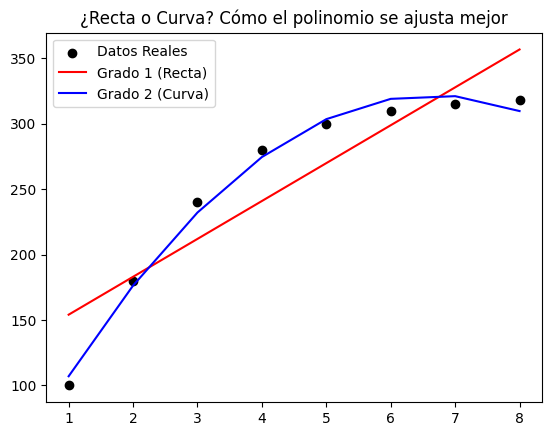

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Creamos datos de ejemplo: Número de habitaciones vs Precio
habitaciones = np.array([1, 2, 3, 4, 5, 6, 7, 8]).reshape(-1, 1)
precios = np.array([100, 180, 240, 280, 300, 310, 315, 318]) # El precio sube, pero cada vez menos

# 1. Modelo Recto (Grado 1)
modelo_recto = LinearRegression().fit(habitaciones, precios)
pred_recta = modelo_recto.predict(habitaciones)

# 2. Modelo Curvo (Grado 2)
poli = PolynomialFeatures(degree=2)
hab_curvas = poli.fit_transform(habitaciones)
modelo_curvo = LinearRegression().fit(hab_curvas, precios)
pred_curva = modelo_curvo.predict(hab_curvas)

# Graficar
plt.scatter(habitaciones, precios, color='black', label='Datos Reales')
plt.plot(habitaciones, pred_recta, color='red', label='Grado 1 (Recta)')
plt.plot(habitaciones, pred_curva, color='blue', label='Grado 2 (Curva)')
plt.legend()
plt.title("¿Recta o Curva? Cómo el polinomio se ajusta mejor")
plt.show()